In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=03bbb80086b2a7b98b4859e0c1254d8a57ebebba6f4f80bab3014d1843d26d08
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# LOAD DATA
filename = '/content/Traindata_20um.csv'
print(f"Loading {filename}...")
df_full = pd.read_csv(filename)
print(f"Original shape: {df_full.shape}")

Loading /content/Traindata_20um.csv...
Original shape: (796130, 54)


In [4]:
# ---(N=xk)---
TARGET_TOTAL_N = 300000

# Get unique classes available in your specific dataset
# We filter only for classes that are relevant (CA, CB, CC, CD, Tails etc)
relevant_classes = [c for c in df_full['Class'].unique() if isinstance(c, str)]
n_classes = len(relevant_classes)
samples_per_class = TARGET_TOTAL_N // n_classes

print(f"\nBalancing: Aiming for ~{samples_per_class} samples per class for {n_classes} classes.")

balanced_dfs = []
for cls in relevant_classes:
    cls_df = df_full[df_full['Class'] == cls]

    if len(cls_df) >= samples_per_class:
        # Downsample if we have too many
        balanced_dfs.append(cls_df.sample(n=samples_per_class, random_state=42))
    else:
        # Keep all if we don't have enough (or we could oversample)
        # For now, we just keep what we have to avoid duplicates
        balanced_dfs.append(cls_df)

df = pd.concat(balanced_dfs).reset_index(drop=True)
print(f"Balanced shape: {df.shape}")
print("\nClass distribution in balanced set:")
print(df['Class'].value_counts())


Balancing: Aiming for ~60000 samples per class for 5 classes.
Balanced shape: (300000, 54)

Class distribution in balanced set:
Class
CA20    60000
CB20    60000
CC20    60000
CD20    60000
TD20    60000
Name: count, dtype: int64


In [5]:
# MAP TO SURVIVAL DATA (Time & Event)
# Time (T): Cumulative flotation time
# Event (E): 1 = Floated (Concentrate), 0 = Not Floated (Tailings/Censored)
def get_time_event(cls_name):
    # cls_name examples: 'CA20', 'CB50', 'TD2032', 'Tail20'
    s = str(cls_name).upper()

    # Identify Fraction (Time)
    if 'CA' in s:
        time = 0.75
        event = 1
    elif 'CB' in s:
        time = 1.50   # Cumulative time
        event = 1
    elif 'CC' in s:
        time = 3.00   # Cumulative time
        event = 1
    elif 'CD' in s:
        time = 6.00   # Cumulative time
        event = 1
    elif 'TD' in s or 'TAIL' in s:
        time = 6.00   # Censored at final collection time
        event = 0     # Did NOT float
    else:
        return None, None # Unknown class
    return time, event
# Apply mapping
df[['T', 'E']] = df['Class'].apply(lambda x: pd.Series(get_time_event(x)))
df = df.dropna(subset=['T', 'E'])





In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [7]:
exclude_cols = ['Class', 'T', 'E', 'sample_weights']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

# Only drop truly constant columns (std == 0 on full dataset)
stds = df[feature_cols].std()
constant_cols = stds[stds == 0].index.tolist()
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant columns: {constant_cols}")
    feature_cols = [c for c in feature_cols if c not in constant_cols]

data_model = df[feature_cols + ['T', 'E']].dropna()
print(f"\nUsing {len(feature_cols)} features on {len(data_model)} rows")
print(feature_cols)

Dropping 2 constant columns: ['Clinochlore', 'Clinochlore.surf']

Using 51 features on 300000 rows
['Actinolite', 'Albite', 'Almandine', 'Apatite', 'Barite', 'Biotite', 'Calcite', 'Chalcopyrite', 'Diopside', 'Dolomite', 'Fluorite', 'Hematite', 'Muscovite', 'Orthoclase', 'Plagioclase', 'Phlogopite', 'Pyrite', 'Pyrrhotite', 'Quartz', 'Rutile', 'Sanidine', 'Sphalerite_Fe', 'Titanite', 'Zircon', 'Actinolite.surf', 'Albite.surf', 'Almandine.surf', 'Apatite.surf', 'Barite.surf', 'Biotite.surf', 'Calcite.surf', 'Chalcopyrite.surf', 'Diopside.surf', 'Dolomite.surf', 'Fluorite.surf', 'Hematite.surf', 'Muscovite.surf', 'Orthoclase.surf', 'Plagioclase.surf', 'Phlogopite.surf', 'Pyrite.surf', 'Pyrrhotite.surf', 'Quartz.surf', 'Rutile.surf', 'Sanidine.surf', 'Sphalerite_Fe.surf', 'Titanite.surf', 'Zircon.surf', 'AspectRatio', 'Solidity', 'ECD']


In [8]:
def remove_collinear(df_in, threshold=10.0, sample_n=50000):
    df_s = df_in.sample(n=min(sample_n, len(df_in)), random_state=42)
    X = df_s.drop(['T', 'E'], axis=1)
    while True:
        vifs = []
        for i in range(len(X.columns)):
            try: vifs.append(variance_inflation_factor(X.values, i))
            except: vifs.append(float('inf'))
        v = pd.DataFrame({'f': X.columns, 'V': vifs})
        mx = v['V'].max()
        if pd.isna(mx) or mx == float('inf') or mx > threshold:
            feat = v.sort_values('V', ascending=False, na_position='first')['f'].iloc[0]
            X = X.drop(columns=[feat])
            print(f"  Dropped collinear: {feat}")
        else: break
    return df_in[X.columns.tolist() + ['T', 'E']]

print("Checking collinearity...")
model_data = remove_collinear(data_model)
final_features = [c for c in model_data.columns if c not in ['T', 'E']]
print(f"\nFeatures after VIF ({len(final_features)}): {final_features}")

Checking collinearity...
  Dropped collinear: Titanite
  Dropped collinear: Titanite.surf
  Dropped collinear: Actinolite
  Dropped collinear: Biotite
  Dropped collinear: Fluorite
  Dropped collinear: Muscovite
  Dropped collinear: Apatite.surf
  Dropped collinear: Sphalerite_Fe
  Dropped collinear: Phlogopite
  Dropped collinear: Sanidine
  Dropped collinear: Barite
  Dropped collinear: Dolomite
  Dropped collinear: Quartz
  Dropped collinear: Calcite
  Dropped collinear: Albite
  Dropped collinear: Orthoclase
  Dropped collinear: Plagioclase
  Dropped collinear: Diopside.surf
  Dropped collinear: Hematite.surf
  Dropped collinear: Rutile.surf
  Dropped collinear: Pyrite.surf
  Dropped collinear: Solidity
  Dropped collinear: Zircon.surf
  Dropped collinear: Pyrrhotite.surf
  Dropped collinear: Chalcopyrite.surf
  Dropped collinear: Almandine
  Dropped collinear: AspectRatio

Features after VIF (24): ['Apatite', 'Chalcopyrite', 'Diopside', 'Hematite', 'Pyrite', 'Pyrrhotite', 'Rutile'

In [9]:

# Test different penalizer values
penalizers = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

results = []
for pen in penalizers:
    cph = CoxPHFitter(penalizer=pen, l1_ratio=1.0)  # l1_ratio=1.0 = pure LASSO
    cph.fit(data_model.drop('sample_weights', axis=1, errors='ignore'),
            duration_col='T', event_col='E')

    # Count non-zero coefficients
    n_nonzero = (cph.params_.abs() > 0.001).sum()

    results.append({
        'penalizer': pen,
        'n_nonzero': n_nonzero,
        'coefs': cph.params_.to_dict()
    })

    print(f"\nPenalizer={pen}, Non-zero features={n_nonzero}")
    print(cph.params_)

# Find penalizer where coefficients start becoming zero
import pandas as pd
coef_df = pd.DataFrame([r['coefs'] for r in results], index=penalizers)
print("\n=== Coefficient Path (LASSO) ===")
print(coef_df.round(4))


Penalizer=0.001, Non-zero features=31
covariate
Actinolite           -0.264223
Albite               -0.000156
Almandine            -0.000949
Apatite               0.591484
Barite                0.001371
Biotite              -1.288089
Calcite               0.000017
Chalcopyrite          0.001277
Diopside              0.000232
Dolomite             -0.000017
Fluorite              0.310825
Hematite             -0.091940
Muscovite            -0.146024
Orthoclase           -0.000238
Plagioclase          -0.185303
Phlogopite           -0.000076
Pyrite                0.030787
Pyrrhotite            0.000245
Quartz               -0.820301
Rutile               -0.000095
Sanidine             -0.000376
Sphalerite_Fe         0.395874
Titanite              0.002848
Zircon               -0.049419
Actinolite.surf      -0.000914
Albite.surf          -1.115321
Almandine.surf       -0.148917
Apatite.surf          0.000007
Barite.surf           0.675192
Biotite.surf         -0.000787
Calcite.surf         

In [10]:
from joblib import Parallel, delayed
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np

n_bootstrap = 1000
all_features = [c for c in model_data.columns if c not in ['T', 'E']]

def fit_one_bootstrap(seed):
    # Subsample to 50k rows for speed
    boot_sample = model_data.sample(n=min(50000, len(model_data)), replace=True, random_state=seed)

    # Per-sample variance check
    sample_stds = boot_sample[all_features].std()
    valid_features = sample_stds[sample_stds > 1e-6].index.tolist()
    boot_clean = boot_sample[valid_features + ['T', 'E']]

    try:
        cph = CoxPHFitter(penalizer=0.02, l1_ratio=1.0)
        cph.fit(boot_clean, duration_col='T', event_col='E')
        return cph.params_.reindex(all_features, fill_value=0.0)
    except:
        return None

print(f"Starting parallel bootstrap ({n_bootstrap} iters, 50k rows each)...")
results = Parallel(n_jobs=-1, verbose=5)(
    delayed(fit_one_bootstrap)(i) for i in range(n_bootstrap)
)

bootstrapped_betas = [r for r in results if r is not None]
boot_results = pd.DataFrame(bootstrapped_betas)

print(f"\nSuccessful fits: {len(boot_results)}/{n_bootstrap}")
print("\n=== Bootstrap + LASSO Results ===")
print("\nMean Coefficients:")
print(boot_results.mean())
print("\n95% Confidence Intervals:")
print(boot_results.quantile([0.025, 0.975]).T)
print("\nStandard Errors:")
print(boot_results.std())

Starting parallel bootstrap (1000 iters, 50k rows each)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   36.5s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:  6.2min
[Parallel(n_jobs=-1)]: Done 284 tasks      | elapsed: 11.1min
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed: 17.4min
[Parallel(n_jobs=-1)]: Done 644 tasks      | elapsed: 25.1min
[Parallel(n_jobs=-1)]: Done 878 tasks      | elapsed: 34.3min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed: 39.1min finished



Successful fits: 1000/1000

=== Bootstrap + LASSO Results ===

Mean Coefficients:
covariate
Apatite               5.511484e-01
Chalcopyrite          4.312855e-06
Diopside              2.647746e-07
Hematite             -3.917728e-06
Pyrite                5.208906e-07
Pyrrhotite            1.291514e-06
Rutile               -3.347825e-07
Zircon                1.491205e-06
Actinolite.surf      -3.014358e-06
Albite.surf          -5.180422e-01
Almandine.surf       -2.072830e-06
Barite.surf           5.767700e-06
Biotite.surf         -1.047544e-03
Calcite.surf          9.188732e-05
Dolomite.surf        -2.596455e-07
Fluorite.surf         7.214712e-06
Muscovite.surf       -7.800632e-06
Orthoclase.surf      -2.983511e-01
Plagioclase.surf     -5.527654e-04
Phlogopite.surf      -9.909422e-01
Quartz.surf          -5.229827e-01
Sanidine.surf        -2.134505e-01
Sphalerite_Fe.surf    3.454699e-06
ECD                   2.334461e-02
dtype: float64

95% Confidence Intervals:
                         

In [20]:
# Save bootstrap results to CSV
boot_results.mean().to_csv('bootstrap_mean_coefficients.csv', header=['mean_coef'])
boot_results.std().to_csv('bootstrap_std_errors.csv', header=['std_error'])
boot_results.quantile([0.025, 0.975]).T.to_csv('bootstrap_confidence_intervals.csv')

# Save everything in one neat table
summary = pd.DataFrame({
    'Mean Coef': boot_results.mean(),
    'Std Error': boot_results.std(),
    'CI 2.5%': boot_results.quantile(0.025),
    'CI 97.5%': boot_results.quantile(0.975)
})
summary.to_csv('bootstrap_summary.csv')
print("Saved to bootstrap_summary.csv")
print(summary)

Saved to bootstrap_summary.csv
                       Mean Coef     Std Error       CI 2.5%      CI 97.5%
covariate                                                                 
Apatite             5.511484e-01  1.134701e-02  5.293183e-01  5.729767e-01
Chalcopyrite        4.312855e-06  1.662446e-05 -1.344356e-05  6.588692e-05
Diopside            2.647746e-07  1.010829e-06 -1.744510e-06  2.220997e-06
Hematite           -3.917728e-06  2.386058e-06 -9.301010e-06  5.625354e-07
Pyrite              5.208906e-07  4.851374e-07 -3.753105e-07  1.530922e-06
Pyrrhotite          1.291514e-06  1.113551e-06 -8.406215e-07  3.673230e-06
Rutile             -3.347825e-07  2.265653e-06 -4.916378e-06  3.881425e-06
Zircon              1.491205e-06  3.783598e-05 -4.679667e-05  2.512440e-05
Actinolite.surf    -3.014358e-06  3.194700e-06 -9.317683e-06  2.869093e-06
Albite.surf        -5.180422e-01  8.253698e-02 -6.859827e-01 -3.556047e-01
Almandine.surf     -2.072830e-06  2.384180e-05 -1.969334e-05  1.97009

In [12]:
# Variance check on full data (same as bootstrap loop)
all_features = [c for c in model_data.columns if c not in ['T', 'E']]
f_stds = model_data[all_features].std()
valid_final = f_stds[f_stds > 1e-6].index.tolist()
final_data = model_data[valid_final + ['T', 'E']]

# Fit final model on ALL 300k rows
cph_final = CoxPHFitter(penalizer=0.02, l1_ratio=1.0)
cph_final.fit(final_data, duration_col='T', event_col='E')

# Override coefficients with bootstrap means (aligned to final model's features)
cph_final.params_ = boot_results.mean().reindex(cph_final.params_.index, fill_value=0.0)

print("\n=== Final Model Summary (using Bootstrap means) ===")
cph_final.print_summary()


=== Final Model Summary (using Bootstrap means) ===


<lifelines.CoxPHFitter: fitted with 300000 total observations, 60000 right-censored observations>
             duration col = 'T'
                event col = 'E'
                penalizer = 0.02
                 l1 ratio = 1.0
      baseline estimation = breslow
   number of observations = 300000
number of events observed = 240000
   partial log-likelihood = -2867564.18
         time fit was run = 2026-03-13 19:37:54 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
Apatite             0.55      1.74      0.00            0.54            0.56                1.72                1.75
Chalcopyrite        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Diopside            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Hematite           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Pyrite              0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Pyrrhotite          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Rutile             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Zircon             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Actinolite.surf    -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Albite.surf        -0.51      0.60      0.03           -0.58           -0.45                0.56                0.64
Almandine.surf     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Barite.surf         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Biotite.surf       -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Calcite.surf        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Dolomite.surf      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Fluorite.surf       0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Muscovite.surf     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Orthoclase.surf    -0.30      0.74      0.04           -0.38           -0.23                0.68                0.80
Plagioclase.surf   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Phlogopite.surf    -0.99      0.37      0.02           -1.03           -0.95                0.36                0.39
Quartz.surf        -0.52      0.59      0.02           -0.56           -0.48                0.57                0.62
Sanidine.surf      -0.21      0.81      0.06           -0.32           -0.10                0.72                0.90
Sphalerite_Fe.surf  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ECD                 0.02      1.02      0.00            0.02            0.02                1.02                1.02

                    cmp to      z      p  -log2(p)
covariate                                         
Apatite               0.00 119.74 <0.005       inf
Chalcopyrite          0.00   0.00   1.00      0.00
Diopside              0.00   0.00   1.00      0.00
Hematite              0.00  -0.01   0.99      0.02
Pyrite                0.00   0.01   0.99      0.01
Pyrrhotite            0.00   0.01   0.99      0.01
Rutile                0.00  -0.00   1.00      0.00
Zircon                0.00  -0.00   1.00      0.00
Actinolite.surf  

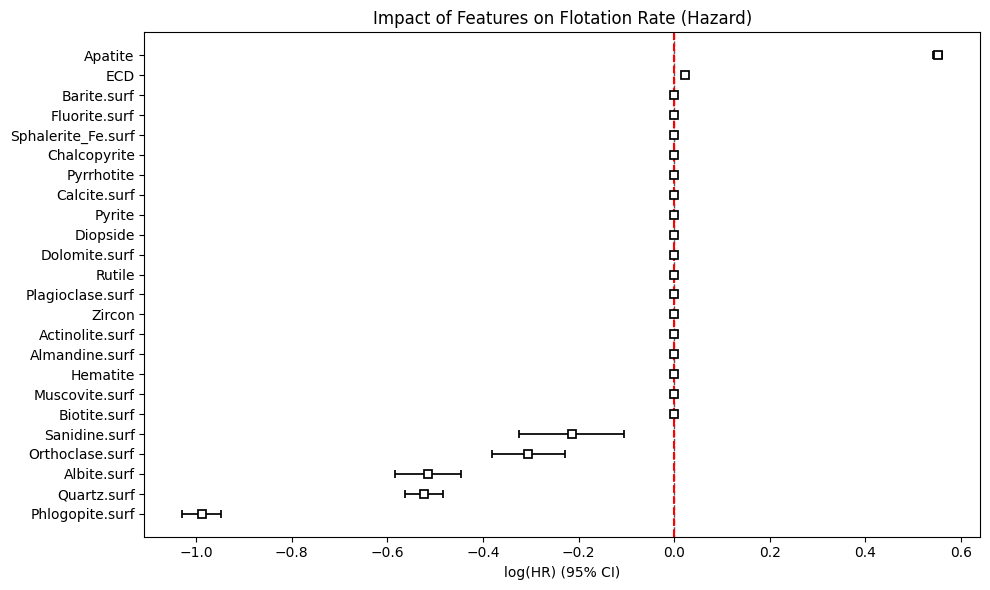

<Figure size 1000x600 with 0 Axes>

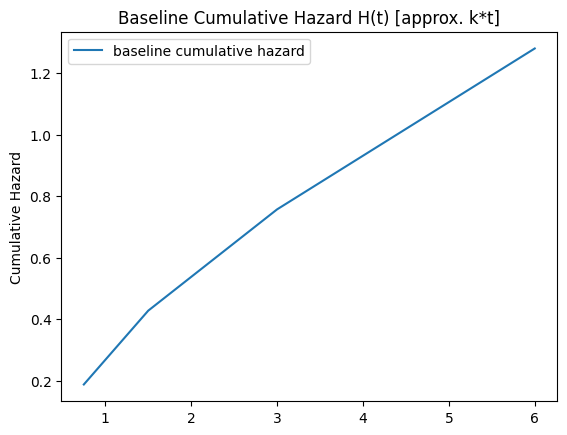

In [13]:
# VISUALIZATION
# Plot coefficients (impact of features)
plt.figure(figsize=(10, 6))
cph_final.plot()
plt.title("Impact of Features on Flotation Rate (Hazard)")
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()
# Plot Cumulative Hazard (related to Kinetic Rate k)
plt.figure(figsize=(10, 6))
cph_final.baseline_cumulative_hazard_.plot()
plt.title("Baseline Cumulative Hazard H(t) [approx. k*t]")
plt.ylabel("Cumulative Hazard")
plt.show()

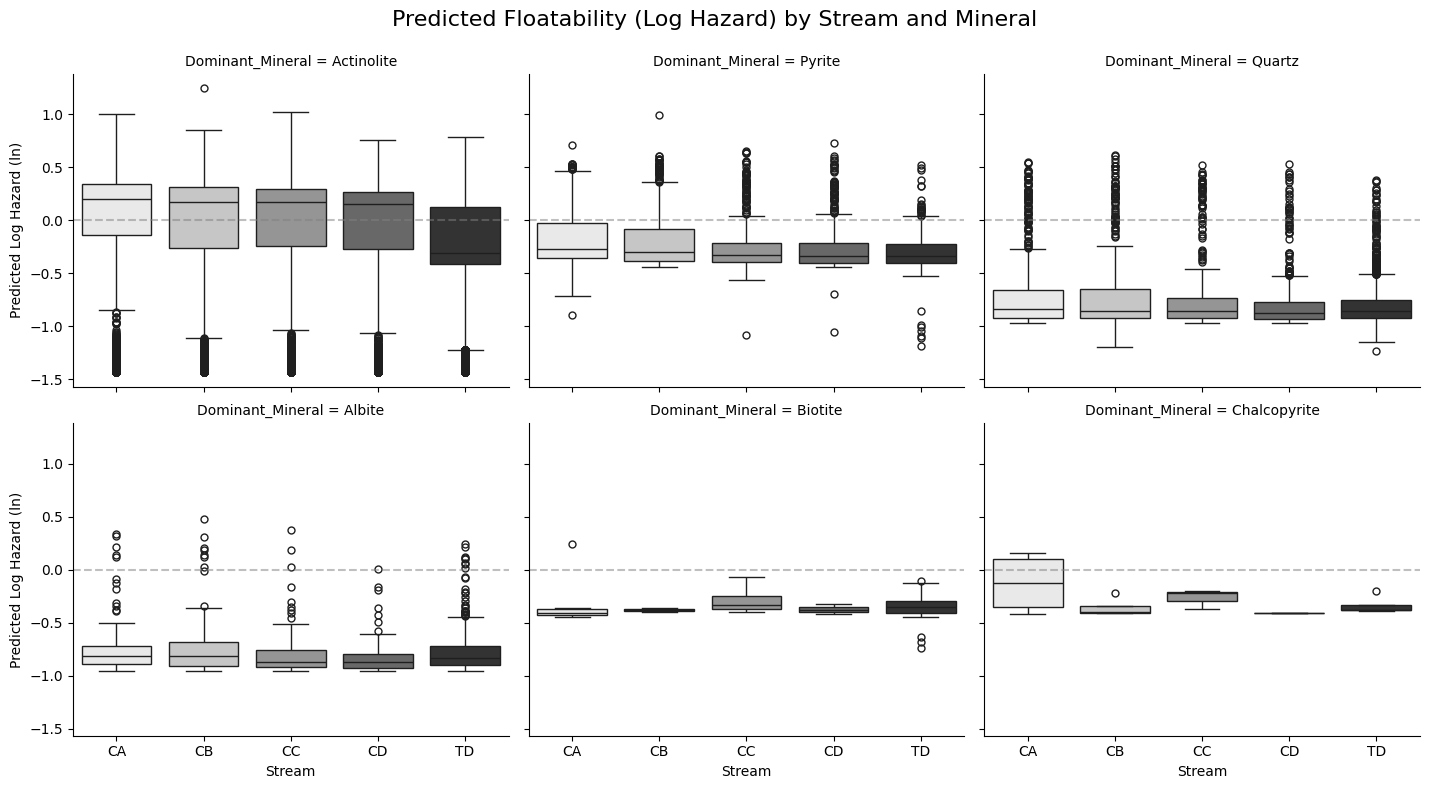

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# This represents the "Floatability Risk" of each particle predicted by the model
# High Value (>0) = Predicted to float EARLY (CA)
# Low Value (<0) = Predicted to float LATE or NEVER (TD)
df['Predicted_LogHazard'] = cph_final.predict_log_partial_hazard(data_model)

# 2. Extract Stream Label (CA, CB, CC...) for X-axis
def get_stream(cls):
    cls = str(cls).upper()
    if 'CA' in cls: return 'CA'
    if 'CB' in cls: return 'CB'
    if 'CC' in cls: return 'CC'
    if 'CD' in cls: return 'CD'
    if 'TD' in cls or 'TAIL' in cls: return 'TD'
    return 'Other'

df['Stream'] = df['Class'].apply(get_stream)

# Determine Dominant Mineral for Facteting
# We look at the mineral columns and see which one is highest for each particle
mineral_columns = ['Actinolite', 'Albite', 'Biotite', 'Chalcopyrite', 'Pyrite', 'Quartz']
# Make sure these columns exist in your df
valid_minerals = [m for m in mineral_columns if m in df.columns]

if valid_minerals:
    df['Dominant_Mineral'] = df[valid_minerals].idxmax(axis=1)
else:
    df['Dominant_Mineral'] = 'Unknown'

# Create the Faceted Boxplot
# kind='box' -> Boxplot
# col='Dominant_Mineral' -> Separate plot for each mineral
# col_wrap=3 -> Start new row after 3 plots
g = sns.catplot(
    data=df,
    x='Stream',
    y='Predicted_LogHazard',
    col='Dominant_Mineral',
    kind='box',
    col_wrap=3,
    height=4,
    aspect=1.2,
    order=['CA', 'CB', 'CC', 'CD', 'TD'], # Force correct order
    palette='Greys' # Matches the black/white style of your image
)

# Styling adjustments to match your image
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Predicted Floatability (Log Hazard) by Stream and Mineral', fontsize=16)
g.set_axis_labels("Stream", "Predicted Log Hazard (ln)")

# Add a reference line at 0 (Average Floatability)
for ax in g.axes.flat:
    ax.axhline(0, ls='--', c='gray', alpha=0.5)

plt.show()

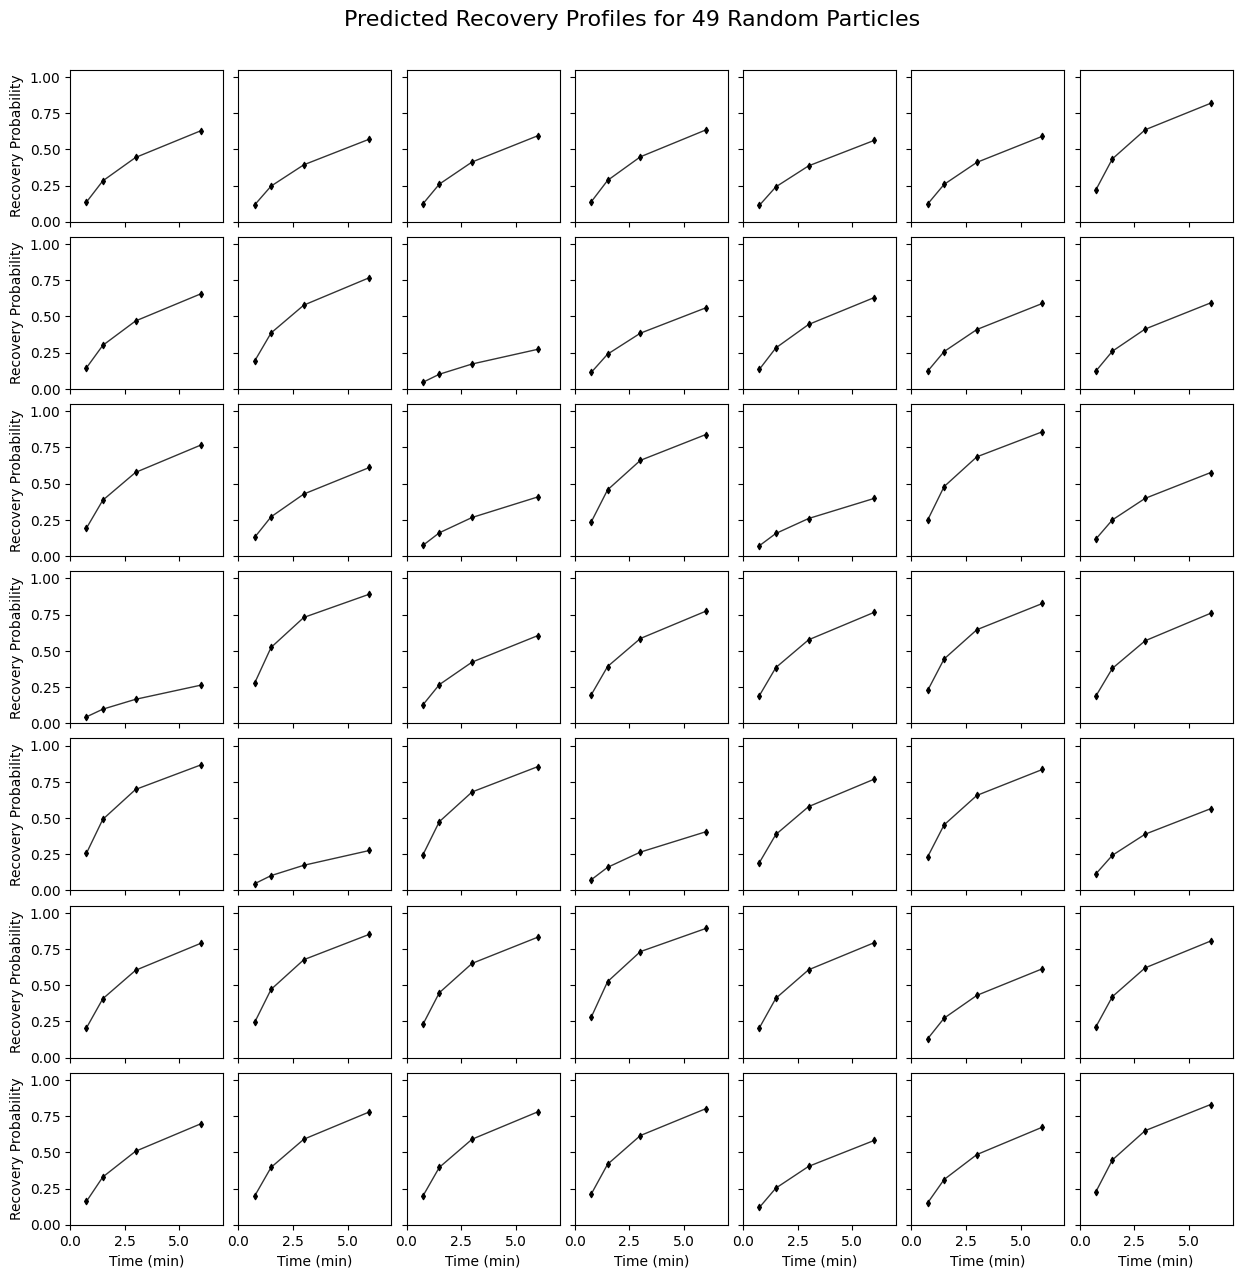

In [15]:


# REAL INDIVIDUAL PARTICLE CURVES (49 Random Particles)

# Select 49 random particles from the dataset
# We use replace=False to get unique particles
np.random.seed(42)  # For reproducibility
random_indices = np.random.choice(data_model.index, 49, replace=False)
sample_particles = data_model.loc[random_indices]

# Predict Survival Functions for these 49 particles
# Result is a DataFrame: Index = Time, Columns = Particle IDs
try:
    # predict_survival_function expects just covariance data, usually handles dropping T/E automatically
    # but safer to pass only features if explicit
    features_only = sample_particles.drop(['T', 'E'], axis=1)
    survival_curves_49 = cph_final.predict_survival_function(features_only)
except:
    survival_curves_49 = cph_final.predict_survival_function(sample_particles)

# Convert to Recovery: R(t) = 1 - S(t)
recovery_curves_49 = 1 - survival_curves_49

# Plotting 7x7 Grid
fig, axes = plt.subplots(7, 7, figsize=(15, 15), sharex=True, sharey=True)
axes = axes.flatten()

# Get the time steps for plotting (the index of the survival dataframe)
times = recovery_curves_49.index

for i, ax in enumerate(axes):
    # Get particle ID
    particle_id = recovery_curves_49.columns[i]

    # Get expected recovery curve values
    y_values = recovery_curves_49[particle_id].values

    # Plot the curve
    ax.plot(times, y_values, color='black', linewidth=1, alpha=0.8)

    # Add dots for the specific measured time points (0.75, 1.5, 3.0, 6.0)
    # Note: Since this is a model prediction, these points lie ON the line
    experimental_times = [0.75, 1.5, 3.0, 6.0]
    # Interpolate to find exact Y value at these specific X times
    y_points = np.interp(experimental_times, times, y_values)
    ax.scatter(experimental_times, y_points, color='black', s=10, marker='d') # 'd' for diamond marker


    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 7)


    if i < 42:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Time (min)')

    if i % 7 != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Recovery Probability')

plt.suptitle("Predicted Recovery Profiles for 49 Random Particles", fontsize=16, y=0.92)
plt.subplots_adjust(wspace=0.1, hspace=0.1) # Tight layout
plt.show()

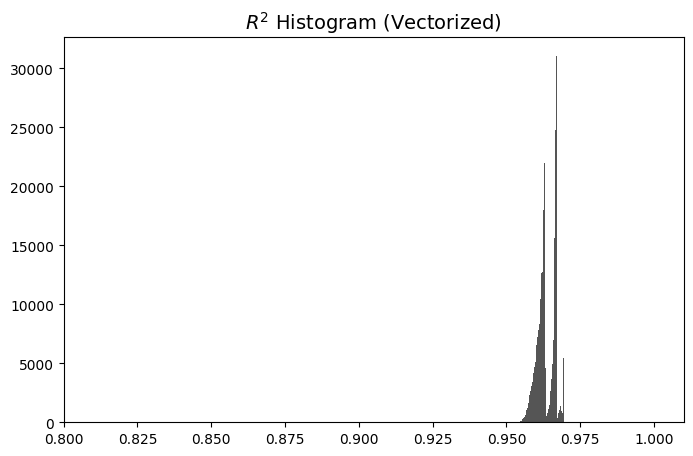

Mean R2: 0.96333


In [16]:
# Define time points and baseline hazard
time_pts = np.array([0.75, 1.5, 3.0, 6.0])
baseline_h = cph_final.baseline_cumulative_hazard_
h0 = np.array([baseline_h.iloc[np.abs(baseline_h.index.values - t).argmin(), 0] for t in time_pts])

# Get the "risk" for all 300k particles at once
# ph shape: (300000, 1)
ph = cph_final.predict_partial_hazard(model_data).values.reshape(-1, 1)

# Calculate Cox recovery for all particles at all time points
# y_obs shape: (300000, 4)
y_obs = 1 - np.exp(-ph * h0)

# Fast First-Order Fit (Linearized k = sum(t*y)/sum(t^2))
# This is mathematically the "best fit" k for each particle's curve
k = ph * (np.sum(time_pts * h0) / np.sum(time_pts**2))

# Calculate R2 for all rows at once
y_pred = 1 - np.exp(-k * time_pts)
y_mean = np.mean(y_obs, axis=1, keepdims=True)

ss_res = np.sum((y_obs - y_pred)**2, axis=1)
ss_tot = np.sum((y_obs - y_mean)**2, axis=1)

# Handle cases with no variance
r2_values = 1 - (ss_res / ss_tot)
r2_values[ss_tot == 0] = 1.0

# Plotting
plt.figure(figsize=(8, 5))
plt.hist(r2_values, bins=100, color='#555555', edgecolor='none')
plt.title('$R^2$ Histogram (Vectorized)', fontsize=14)
plt.xlim(0.8, 1.01)
plt.show()

print(f"Mean R2: {np.nanmean(r2_values):.5f}")

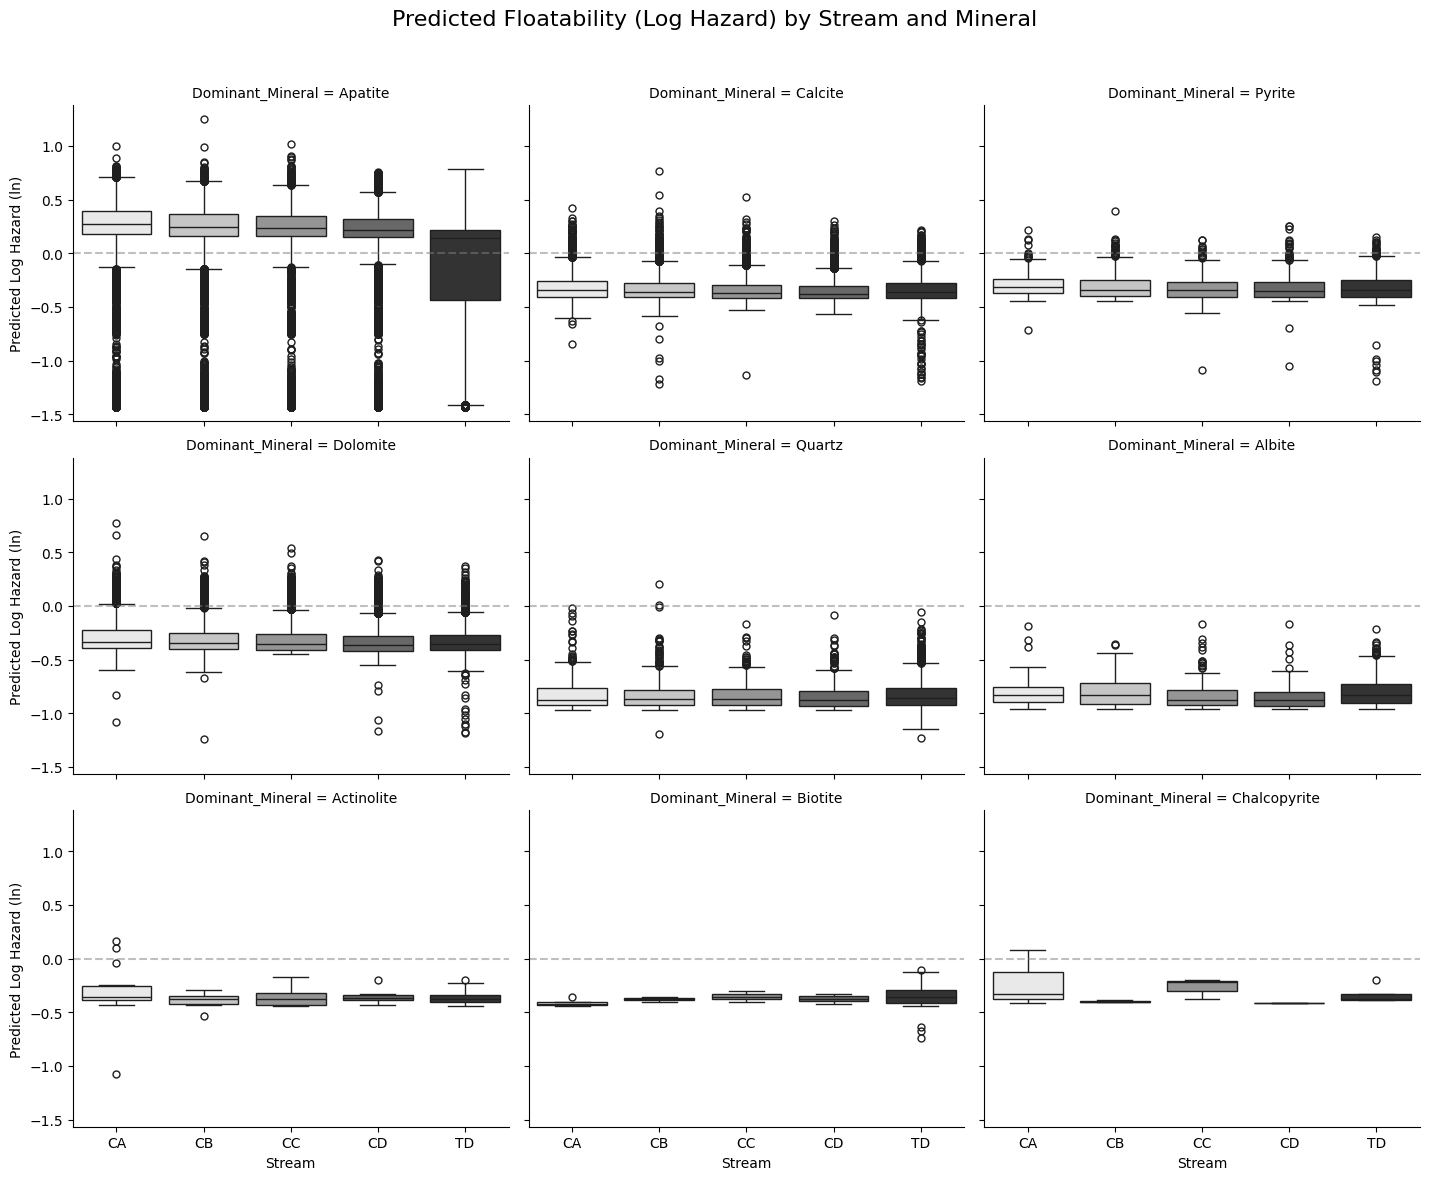

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Predicted_LogHazard'] = cph_final.predict_log_partial_hazard(data_model)

def get_stream(cls):
    cls = str(cls).upper()
    if 'CA' in cls: return 'CA'
    if 'CB' in cls: return 'CB'
    if 'CC' in cls: return 'CC'
    if 'CD' in cls: return 'CD'
    if 'TD' in cls or 'TAIL' in cls: return 'TD'
    return 'Other'

df['Stream'] = df['Class'].apply(get_stream)

mineral_columns = [
    'Apatite',          # Ore mineral
    'Calcite',          # Carbonate gangue
    'Dolomite',         # Carbonate gangue
    'Albite',           # Silicate gangue
    'Quartz',           # Silicate gangue
    'Actinolite',       # Silicate
    'Chalcopyrite',     # Sulfide
    'Pyrite',           # Sulfide
    'Biotite',          # Phyllosilicate
]
valid_minerals = [m for m in mineral_columns if m in df.columns]

if valid_minerals:
    df['Dominant_Mineral'] = df[valid_minerals].idxmax(axis=1)
else:
    df['Dominant_Mineral'] = 'Unknown'

g = sns.catplot(
    data=df,
    x='Stream',
    y='Predicted_LogHazard',
    col='Dominant_Mineral',
    kind='box',
    col_wrap=3,
    height=4,
    aspect=1.2,
    order=['CA', 'CB', 'CC', 'CD', 'TD'],
    palette='Greys'
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Predicted Floatability (Log Hazard) by Stream and Mineral', fontsize=16)
g.set_axis_labels("Stream", "Predicted Log Hazard (ln)")

for ax in g.axes.flat:
    ax.axhline(0, ls='--', c='gray', alpha=0.5)

plt.show()

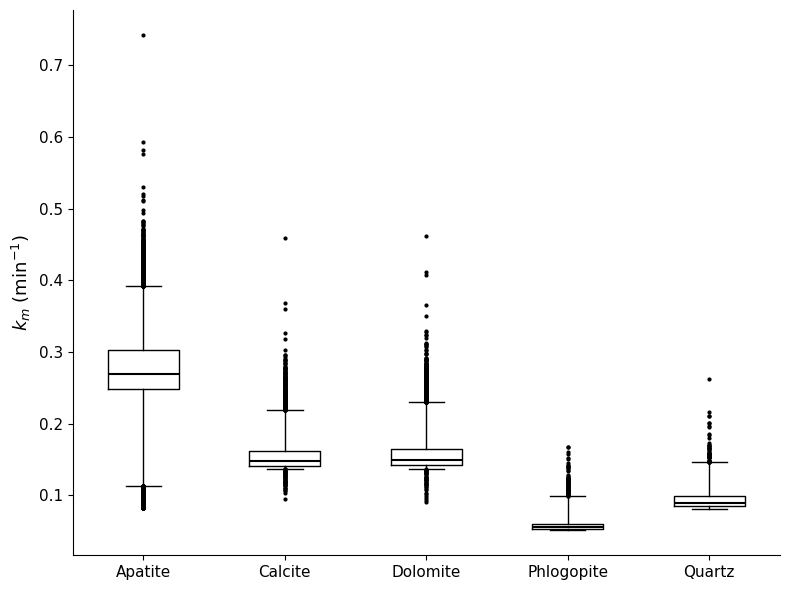

Apatite          median=0.2690  mean=0.2755  n=188484
Calcite          median=0.1485  mean=0.1544  n=32740
Dolomite         median=0.1497  mean=0.1568  n=67451
Phlogopite       median=0.0552  mean=0.0582  n=6629
Quartz           median=0.0899  mean=0.0941  n=4696


In [17]:
import matplotlib.pyplot as plt
import numpy as np


baseline_h = cph_final.baseline_cumulative_hazard_
H0_max = baseline_h.iloc[-1, 0]
t_max = baseline_h.index[-1]
k_baseline = H0_max / t_max  # Slope of baseline hazard

partial_hazards = cph_final.predict_partial_hazard(data_model).values.flatten()
df.loc[data_model.index, 'k_m'] = partial_hazards * k_baseline

minerals_of_interest = ['Apatite', 'Calcite', 'Dolomite', 'Phlogopite', 'Quartz']
valid_minerals = [m for m in minerals_of_interest if m in df.columns]

df['Main_Mineral'] = df[valid_minerals].idxmax(axis=1)

plot_df = df[df['k_m'].notna() & df['Main_Mineral'].isin(minerals_of_interest)].copy()

fig, ax = plt.subplots(figsize=(8, 6))

grouped = [plot_df[plot_df['Main_Mineral'] == m]['k_m'].values for m in minerals_of_interest]

bp = ax.boxplot(
    grouped,
    labels=minerals_of_interest,
    whis=[1, 99],
    showfliers=True,
    flierprops=dict(marker='.', markersize=4, markerfacecolor='black', markeredgecolor='black'),
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    patch_artist=False
)

ax.set_ylabel(r'$k_m$ (min$^{-1}$)', fontsize=13)
ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

for m in minerals_of_interest:
    vals = plot_df[plot_df['Main_Mineral'] == m]['k_m']
    print(f"{m:15s}  median={vals.median():.4f}  mean={vals.mean():.4f}  n={len(vals)}")

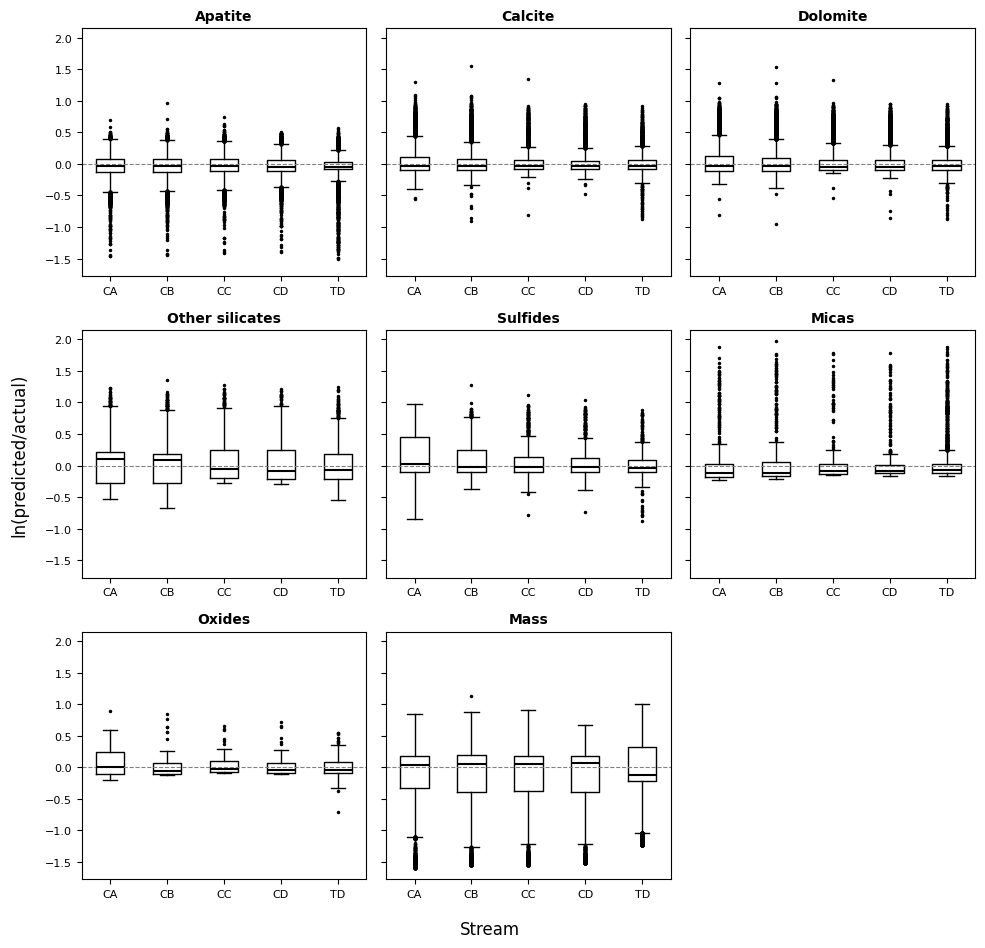

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Mineral group definitions (adjust column names to match your data) ---
MINERAL_GROUPS = {
    'Apatite':         ['Apatite'],
    'Calcite':         ['Calcite'],
    'Dolomite':        ['Dolomite'],
    'Other silicates': ['Albite', 'Orthoclase', 'Plagioclase', 'Sanidine',
                        'Quartz', 'Actinolite', 'Diopside', 'Almandine',
                        'Zircon', 'Fluorite', 'Titanite'],
    'Sulfides':        ['Chalcopyrite', 'Pyrite', 'Pyrrhotite',
                        'Sphalerite_Fe', 'Barite'],
    'Micas':           ['Biotite', 'Muscovite', 'Phlogopite'],
    'Oxides':          ['Hematite', 'Rutile'],
}

PANEL_ORDER  = ['Apatite', 'Calcite', 'Dolomite',
                'Other silicates', 'Sulfides', 'Micas',
                'Oxides', 'Mass']
STREAM_ORDER = ['CA', 'CB', 'CC', 'CD', 'TD']

# --- 2. Extract stream label from 'Class' ---
def get_stream(cls_name):
    s = str(cls_name).upper()
    for tag in STREAM_ORDER:
        if tag in s:
            return tag
    if 'TAIL' in s:
        return 'TD'
    return None

# --- 3. Compute ln(predicted / actual) per stream per mineral group ---
if 'Stream' not in df.columns:
    df['Stream'] = df['Class'].apply(get_stream)

pred_hazard = cph_final.predict_partial_hazard(model_data)
df['pred_hazard'] = pred_hazard.values

rows = []
for stream in STREAM_ORDER:
    sub = df[df['Stream'] == stream].copy()
    if len(sub) == 0:
        continue
    n = len(sub)

    # --- Mass panel ---
    actual_mass = np.ones(n) / n
    pred_mass   = sub['pred_hazard'].values
    pred_mass   = pred_mass / pred_mass.sum()
    valid = (actual_mass > 0) & (pred_mass > 0)
    if valid.any():
        ln_r = np.log(pred_mass[valid] / actual_mass[valid])
        for v in ln_r:
            rows.append({'Stream': stream, 'MineralGroup': 'Mass',
                         'ln_ratio': v})

    # --- Mineral-group panels ---
    for grp, members in MINERAL_GROUPS.items():
        existing = [m for m in members if m in df.columns]
        if not existing:
            continue
        actual = sub[existing].sum(axis=1).values
        total_a = actual.sum()
        if total_a == 0:
            continue
        actual_frac = actual / total_a

        pred = actual * sub['pred_hazard'].values
        total_p = pred.sum()
        if total_p == 0:
            continue
        pred_frac = pred / total_p

        valid = (actual_frac > 0) & (pred_frac > 0)
        if valid.any():
            ln_r = np.log(pred_frac[valid] / actual_frac[valid])
            for v in ln_r:
                rows.append({'Stream': stream, 'MineralGroup': grp,
                             'ln_ratio': v})

plot_df = pd.DataFrame(rows)

# --- 4. Draw the 3×3 faceted boxplot ---
fig, axes = plt.subplots(3, 3, figsize=(10, 10), sharey=True)
axes_flat = axes.flatten()

for idx, panel in enumerate(PANEL_ORDER):
    ax  = axes_flat[idx]
    sub = plot_df[plot_df['MineralGroup'] == panel]

    data = [sub.loc[sub['Stream'] == s, 'ln_ratio'].values
            for s in STREAM_ORDER]

    ax.boxplot(data, labels=STREAM_ORDER, widths=0.5,
               patch_artist=False,
               medianprops=dict(color='black', linewidth=1.5),
               flierprops=dict(marker='.', markersize=3,
                               markerfacecolor='black',
                               markeredgecolor='black'))
    ax.set_title(panel, fontsize=10, fontweight='bold')
    ax.axhline(0, ls='--', color='gray', linewidth=0.8)
    ax.tick_params(axis='both', labelsize=8)

# hide the unused 9th subplot
axes_flat[-1].set_visible(False)

fig.text(0.5,  0.02, 'Stream',               ha='center', fontsize=12)
fig.text(0.02, 0.5,  'ln(predicted/actual)',  va='center',
         rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])
plt.show()
